# Lucro vira caixa? O passo a passo em Python

Este notebook acompanha o artigo **"Python + Power BI + dados da CVM: como testar se o lucro vira caixa"** e executa,
célula por célula, as etapas em Python: do arquivo no formato da CVM até a tabela pronta para o Power BI.

- A empresa do exemplo, **Mineradora Pedra Clara S.A., não existe**. Os dados são fictícios e foram escritos no mesmo
  formato em que a CVM publica o ITR e a DFP.
- Os valores dos arquivos estão em **R$ mil**; as tabelas e os gráficos daqui mostram **R$ bilhões**.
- A numeração das etapas é a mesma do artigo. O script [`analise_lucro_caixa.py`](https://github.com/Rodrigo-Antonio-Silva/caixa-lucro/blob/main/analise_lucro_caixa.py)
  faz tudo isto de uma vez; aqui o caminho aparece aberto, com o resultado de cada passo.

## Etapa 1: Prepare o ambiente

Você precisa de Python 3.10 ou superior com `pandas`, `scipy`, `matplotlib` e `openpyxl`. Os dados de exemplo já estão
na pasta `dados/` do repositório. Se o notebook estiver rodando fora dela (no Google Colab, por exemplo), a célula
abaixo baixa o repositório antes de continuar.

In [1]:
import os
from pathlib import Path

if not Path("dados/resultados_itr_dfp.csv").exists():      # fora da pasta do projeto: baixa o repositório
    !git clone -q https://github.com/Rodrigo-Antonio-Silva/caixa-lucro.git
    os.chdir("caixa-lucro")

import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

DADOS = Path("dados")

RESULTADO = ["receita_liquida", "resultado_bruto", "resultado_antes_financeiro_tributos",
             "resultado_financeiro", "resultado_antes_tributos", "lucro_liquido"]            # DRE
FLUXO = ["caixa_operacional", "caixa_investimento", "caixa_financiamento"]                   # DFC
SALDO = ["divida_bruta", "divida_liquida", "caixa_e_equivalentes"]                           # balanço

CINZA, VERDE, VERMELHO = "#B8C4C4", "#007E7A", "#991310"


def bi(serie):
    return serie / 1e6          # R$ mil -> R$ bilhões

## Etapa 2: Entenda o formato do arquivo (Crítico!)

Cada linha do arquivo tem um `periodo_inicio` e um `periodo_fim`. Veja as linhas de 2024:

In [2]:
df = pd.read_csv(DADOS / "resultados_itr_dfp.csv", parse_dates=["periodo_inicio", "periodo_fim"])
df["ano"] = df["periodo_fim"].dt.year
df["mes_inicio"] = df["periodo_inicio"].dt.month
df["mes_fim"] = df["periodo_fim"].dt.month

linhas_2024 = df[df["ano"] == 2024].sort_values(["periodo_fim", "periodo_inicio"])
linhas_2024[["tipo_relatorio", "periodo_inicio", "periodo_fim", "lucro_liquido", "caixa_operacional"]]

,tipo_relatorio,periodo_inicio,periodo_fim,lucro_liquido,caixa_operacional
6,ITR,2024-01-01,2024-03-31,1615000.0,2845000.0
7,ITR,2024-01-01,2024-06-30,4300000.0,4440000.0
8,ITR,2024-04-01,2024-06-30,2685000.0,NaN
9,ITR,2024-01-01,2024-09-30,6794000.0,6334000.0
10,ITR,2024-07-01,2024-09-30,2494000.0,NaN
11,DFP,2024-01-01,2024-12-31,4762000.0,9652000.0


Três coisas para notar:

- As linhas que começam em janeiro são **acumuladas no ano**. O caixa operacional de junho (R$ 4,4 bilhões) soma seis
  meses; o de setembro (6,3), nove; a DFP (9,7), o ano inteiro.
- As linhas de abril a junho e de julho a setembro trazem o lucro só do trimestre, mas o caixa operacional está vazio:
  no ITR, a demonstração dos fluxos de caixa só é publicada acumulada.
- Não há linha para o 4º trimestre.

> *Esta é a pegadinha que mais derruba quem começa: se você tratar cada linha como um trimestre, o caixa parecerá
> crescer ao longo do ano por pura aritmética. O erro é silencioso, porque os números são plausíveis.*

Para não depender da diferença entre DRE e fluxo de caixa, a etapa seguinte usa só as linhas que começam em janeiro
e aplica a mesma regra a tudo.

## Etapa 3: Desacumule os trimestres

A regra é uma subtração: o valor isolado é o acumulado até o trimestre menos o acumulado até o trimestre anterior.
O 4º trimestre é a DFP menos os nove meses.

Repare na separação entre **fluxo** e **saldo**. Receita, lucro e caixa gerado são fluxos e se subtraem. Dívida e saldo
de caixa são fotografias do fim do período: subtrair uma da outra não produz "a dívida do trimestre".

In [3]:
def desacumular(df):
    ytd = df[df["mes_inicio"] == 1].set_index(["ano", "mes_fim"]).sort_index()   # só as linhas que começam em janeiro
    linhas = []
    for (ano, mes_fim), atual in ytd.iterrows():
        tri = mes_fim // 3
        linha = {"trimestre": f"{ano}-Q{tri}", "ano": ano, "numero_trimestre": tri}
        anterior = ytd.loc[(ano, mes_fim - 3)] if tri > 1 else None
        for col in RESULTADO + FLUXO:                 # DRE e DFC: fluxos, desacumulam
            linha[col] = atual[col] - (anterior[col] if anterior is not None else 0)
        for col in SALDO:                             # balanço: posição no fim do período, não desacumula
            linha[col] = atual[col]
        linhas.append(linha)
    return pd.DataFrame(linhas)


tri = desacumular(df)
print(f"{len(tri)} trimestres isolados, de {tri['trimestre'].iloc[0]} a {tri['trimestre'].iloc[-1]}")
bi(tri.set_index("trimestre")[["receita_liquida", "lucro_liquido", "caixa_operacional"]]).round(2)

14 trimestres isolados, de 2023-Q1 a 2026-Q2


,receita_liquida,lucro_liquido,caixa_operacional
trimestre,,,
2023-Q1,11.2,2.05,3.42
2023-Q2,12.6,2.44,1.54
2023-Q3,13.4,2.66,2.74
2023-Q4,14.1,2.93,4.18
2024-Q1,10.8,1.62,2.84
2024-Q2,12.9,2.68,1.60
2024-Q3,13.8,2.49,1.89
2024-Q4,13.6,-2.03,3.32
2025-Q1,10.5,1.51,0.65


O caixa operacional de 2024, como vem no arquivo e como precisa entrar na análise:

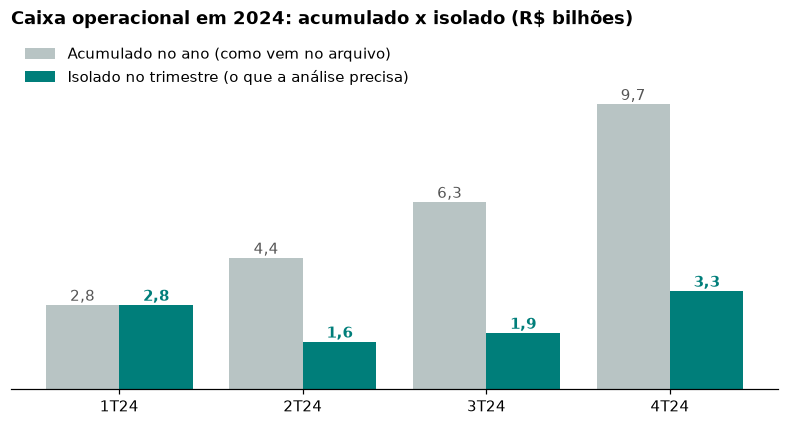

In [4]:
ano = 2024
acumulado = bi(df[(df["mes_inicio"] == 1) & (df["ano"] == ano)].sort_values("mes_fim")["caixa_operacional"])
isolado = bi(tri[tri["ano"] == ano]["caixa_operacional"])

fig, ax = plt.subplots(figsize=(9, 4.2), dpi=110)
x = range(4)
ax.bar([i - 0.2 for i in x], acumulado, width=0.4, color=CINZA, label="Acumulado no ano (como vem no arquivo)")
ax.bar([i + 0.2 for i in x], isolado, width=0.4, color=VERDE, label="Isolado no trimestre (o que a análise precisa)")
for i, (a, b) in enumerate(zip(acumulado, isolado)):
    ax.text(i - 0.2, a + 0.15, f"{a:.1f}".replace(".", ","), ha="center", color="#555")
    ax.text(i + 0.2, b + 0.15, f"{b:.1f}".replace(".", ","), ha="center", color=VERDE, fontweight="bold")
ax.set_xticks(list(x), [f"{q}T{ano % 100}" for q in range(1, 5)])
ax.set_title(f"Caixa operacional em {ano}: acumulado x isolado (R$ bilhões)", loc="left", fontweight="bold")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False, labelleft=False)
ax.set_ylim(0, acumulado.max() * 1.25)
plt.show()

## Etapa 4: Confira contra o total anual

Antes de qualquer análise, vale provar que a conta fecha. A soma dos quatro trimestres isolados de um ano tem de ser
igual à linha da DFP, em todas as contas de resultado e de fluxo de caixa.

In [5]:
def conferir(df, tri):
    dfp = df[df["tipo_relatorio"] == "DFP"].set_index("ano")
    soma = tri[tri["ano"].isin(dfp.index)].groupby("ano")[RESULTADO + FLUXO].sum()
    diferenca = (soma - dfp[RESULTADO + FLUXO]).abs().max().max()
    assert diferenca < 1, f"a soma dos trimestres não bate com a DFP (maior diferença: {diferenca})"
    return diferenca


diferenca = conferir(df, tri)
print(f"Trimestres isolados: {len(tri)}  |  maior diferença contra a DFP: R$ {diferenca:.0f} mil")

dfp = df[df["tipo_relatorio"] == "DFP"].set_index("ano")
soma = tri[tri["ano"].isin(dfp.index)].groupby("ano")[["lucro_liquido", "caixa_operacional"]].sum()
bi(soma.join(dfp[["lucro_liquido", "caixa_operacional"]], lsuffix="_soma_dos_trimestres", rsuffix="_dfp")).round(3)

Trimestres isolados: 14  |  maior diferença contra a DFP: R$ 0 mil


,lucro_liquido_soma_dos_trimestres,caixa_operacional_soma_dos_trimestres,lucro_liquido_dfp,caixa_operacional_dfp
ano,,,,
2023,10.074,11.884,10.074,11.884
2024,4.762,9.652,4.762,9.652
2025,1.630,8.900,1.630,8.900


Se o `assert` falhar, o motivo quase sempre é uma linha acumulada faltando ou duplicada em algum ano. Com dados
reais, uma diferença pequena pode aparecer quando a empresa reapresenta um trimestre. Nesse caso, registre a diferença
e siga; não a esconda.

## Etapa 5: Calcule o gap e teste a relação

Com os trimestres confiáveis, as métricas são diretas. O **gap** é o caixa operacional menos o lucro líquido: positivo
quando o caixa fica acima do lucro. O arquivo `conciliacao_dfc.csv` traz a ponte entre os dois, de onde vem a variação
do capital de giro.

In [6]:
ponte = pd.read_csv(DADOS / "conciliacao_dfc.csv")
m = tri.merge(ponte.drop(columns="caixa_operacional"), on="trimestre", how="left")
m["gap"] = m["caixa_operacional"] - m["lucro_liquido"]                 # > 0: caixa acima do lucro
m["prejuizo_com_caixa_positivo"] = (m["lucro_liquido"] < 0) & (m["caixa_operacional"] > 0)
m["rotulo"] = m["numero_trimestre"].astype(str) + "T" + (m["ano"] % 100).astype(str)

tabela = bi(m.set_index("rotulo")[["lucro_liquido", "caixa_operacional", "gap"]]).round(2)
tabela["prejuizo_com_caixa_positivo"] = m["prejuizo_com_caixa_positivo"].values
tabela

,lucro_liquido,caixa_operacional,gap,prejuizo_com_caixa_positivo
rotulo,,,,
1T23,2.05,3.42,1.37,False
2T23,2.44,1.54,-0.90,False
3T23,2.66,2.74,0.09,False
4T23,2.93,4.18,1.25,False
1T24,1.62,2.84,1.23,False
2T24,2.68,1.60,-1.09,False
3T24,2.49,1.89,-0.60,False
4T24,-2.03,3.32,5.35,True
1T25,1.51,0.65,-0.86,False


### Teste 1: lucro e caixa andam juntos?

A correlação de Pearson entre lucro e caixa, com todos os trimestres e depois sem os trimestres de prejuízo. O segundo
número é o teste de sensibilidade: mostra o quanto a conclusão depende de poucos pontos.

In [7]:
r, p = stats.pearsonr(m["lucro_liquido"], m["caixa_operacional"])
sem = m[~m["prejuizo_com_caixa_positivo"]]
r_sem, p_sem = stats.pearsonr(sem["lucro_liquido"], sem["caixa_operacional"])

print(f"Prejuízo contábil com caixa operacional positivo: {int(m['prejuizo_com_caixa_positivo'].sum())} de {len(m)} trimestres")
print(f"Correlação lucro x caixa: r = {r:+.2f} (p = {p:.2f})")
print(f"  sem os trimestres de prejuízo: r = {r_sem:+.2f} (p = {p_sem:.2f})")

Prejuízo contábil com caixa operacional positivo: 2 de 14 trimestres
Correlação lucro x caixa: r = -0.40 (p = 0.16)
  sem os trimestres de prejuízo: r = +0.28 (p = 0.37)


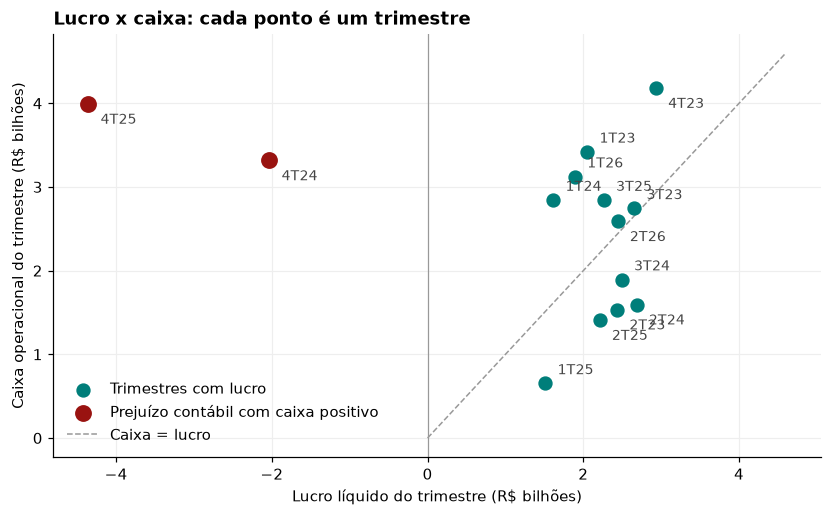

In [8]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=110)
prej = m[m["prejuizo_com_caixa_positivo"]]
ax.scatter(bi(sem["lucro_liquido"]), bi(sem["caixa_operacional"]), s=70, color=VERDE, zorder=3, label="Trimestres com lucro")
ax.scatter(bi(prej["lucro_liquido"]), bi(prej["caixa_operacional"]), s=100, color=VERMELHO, zorder=3,
           label="Prejuízo contábil com caixa positivo")
for i, l in m.iterrows():
    ax.annotate(l["rotulo"], (bi(l["lucro_liquido"]), bi(l["caixa_operacional"])), textcoords="offset points",
                xytext=(8, 6) if i % 2 == 0 else (8, -13), fontsize=9, color="#444")   # alterna para não sobrepor
ax.axvline(0, color="#999", lw=0.8)
lim = [0, bi(m[["lucro_liquido", "caixa_operacional"]]).max().max() * 1.1]
ax.plot(lim, lim, ls="--", color="#999", lw=1, label="Caixa = lucro")
ax.set_xlabel("Lucro líquido do trimestre (R$ bilhões)")
ax.set_ylabel("Caixa operacional do trimestre (R$ bilhões)")
ax.set_title("Lucro x caixa: cada ponto é um trimestre", loc="left", fontweight="bold")
ax.legend(frameon=False, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#eee", zorder=0)
plt.show()

Três leituras saem daqui:

1. Em 2 dos 14 trimestres houve prejuízo contábil com caixa operacional positivo (4T24 e 4T25, em vermelho).
2. A correlação de -0,40 não é estatisticamente significativa (p = 0,16): lucro e caixa não andam juntos nesta amostra.
3. Sem os dois trimestres de prejuízo, a correlação muda de sinal, para +0,28. É o teste de sensibilidade que separa
   uma conclusão de um efeito de dois pontos.

### Teste 2: o gap depende da posição do trimestre no ano?

O gap médio de cada posição (1T, 2T, 3T e 4T), considerando todos os anos.

In [9]:
gap_por_posicao = m.groupby("numero_trimestre").agg(gap_medio=("gap", "mean"), trimestres=("gap", "count"))
gap_por_posicao["gap_medio"] = bi(gap_por_posicao["gap_medio"]).round(2)
gap_por_posicao.index = [f"{q}T" for q in gap_por_posicao.index]
gap_por_posicao

,gap_medio,trimestres
1T,0.74,4
2T,-0.66,4
3T,0.02,3
4T,4.98,3


### Teste 3: nos trimestres em que o caixa fica abaixo do lucro, o capital de giro explica?

Uma hipótese, tratada como hipótese: a amostra é de poucos trimestres, e o valor de p diz isso.

In [10]:
abaixo = m[m["gap"] < 0]                                              # trimestres com caixa abaixo do lucro
r_giro, p_giro = stats.pearsonr(abaixo["gap"], abaixo["variacao_capital_giro"])

print(f"Caixa abaixo do lucro em {len(abaixo)} trimestres, {int(abaixo['numero_trimestre'].isin([2, 3]).sum())} deles no 2T ou 3T")
print(f"  gap x capital de giro nesses trimestres: r = {r_giro:+.2f} (p = {p_giro:.2f})")
bi(abaixo.set_index("rotulo")[["gap", "variacao_capital_giro"]]).round(2)

Caixa abaixo do lucro em 5 trimestres, 4 deles no 2T ou 3T
  gap x capital de giro nesses trimestres: r = +0.76 (p = 0.13)


,gap,variacao_capital_giro
rotulo,,
2T23,-0.90,-1.3
2T24,-1.09,-1.5
3T24,-0.60,-1.2
1T25,-0.86,-1.2
2T25,-0.80,-1.1


## Etapa 6: Monte as tabelas do Power BI

O Power BI recebe duas tabelas em esquema estrela: uma dimensão de tempo (`Calendario`) e uma tabela fato
(`Fato_Trimestral`), ligadas pela coluna `trimestre`. A coluna `ordem` serve para classificar os rótulos na ordem do
tempo, e não em ordem alfabética.

In [11]:
calendario = m[["trimestre", "ano", "numero_trimestre", "rotulo"]].copy()
calendario["ordem"] = range(1, len(calendario) + 1)
calendario["posicao"] = calendario["numero_trimestre"].astype(str) + "T"
fato = m.drop(columns=["ano", "numero_trimestre", "rotulo"])

print(f"Fato_Trimestral: {fato.shape[0]} linhas e {fato.shape[1]} colunas")
calendario

Fato_Trimestral: 14 linhas e 23 colunas


,trimestre,ano,numero_trimestre,rotulo,ordem,posicao
0,2023-Q1,2023,1,1T23,1,1T
1,2023-Q2,2023,2,2T23,2,2T
2,2023-Q3,2023,3,3T23,3,3T
3,2023-Q4,2023,4,4T23,4,4T
4,2024-Q1,2024,1,1T24,5,1T
5,2024-Q2,2024,2,2T24,6,2T
6,2024-Q3,2024,3,3T24,7,3T
7,2024-Q4,2024,4,4T24,8,4T
8,2025-Q1,2025,1,1T25,9,1T
9,2025-Q2,2025,2,2T25,10,2T


Para gravar o arquivo, troque `GRAVAR` para `True`. O repositório já traz `saida/lucro_caixa_tratado.xlsx`, gravado
pelo script com estas mesmas tabelas.

In [12]:
GRAVAR = False

if GRAVAR:
    Path("saida").mkdir(exist_ok=True)
    with pd.ExcelWriter("saida/lucro_caixa_tratado.xlsx", engine="openpyxl") as xl:
        calendario.to_excel(xl, sheet_name="Calendario", index=False)
        fato.to_excel(xl, sheet_name="Fato_Trimestral", index=False)

## Conferência final

Os números abaixo são os citados no artigo, e as tabelas têm de ser iguais às do Excel gravado pelo script. Se algum
dado ou regra mudar, esta célula falha.

In [13]:
assert len(m) == 14 and int(m["prejuizo_com_caixa_positivo"].sum()) == 2
assert (round(r, 2), round(p, 2)) == (-0.40, 0.16)
assert (round(r_sem, 2), round(p_sem, 2)) == (0.28, 0.37)
assert (len(abaixo), round(r_giro, 2), round(p_giro, 2)) == (5, 0.76, 0.13)

arquivo = Path("saida/lucro_caixa_tratado.xlsx")
pd.testing.assert_frame_equal(pd.read_excel(arquivo, sheet_name="Calendario"), calendario, check_dtype=False)
pd.testing.assert_frame_equal(pd.read_excel(arquivo, sheet_name="Fato_Trimestral"), fato, check_dtype=False)

print("Tudo confere: os números do artigo e as duas tabelas do Excel.")

Tudo confere: os números do artigo e as duas tabelas do Excel.


## Daqui em diante é Power BI

As etapas 7 e 8 do artigo continuam no Power BI Desktop: carregar o Excel, conferir o relacionamento entre
`Calendario` e `Fato_Trimestral`, escrever as medidas em DAX e montar as páginas do painel.